# Sistema de planificación de jornadas

- **Autor:** Luis Miguel Marín Cadavid
- **Fecha:** 16 Julio 2026
- **Fase 3:** Sistema integrado de optimización y simulación para jornadas reales

---

## Objetivo

Permitir al usuario ingresar los parámetros reales de una jornada de despachos 
(lista de rutas, número de operadores disponibles, eventos del día) y obtener 
un diagnóstico completo de viabilidad que integre:

- **Optimización matemática** para asignación balanceada de rutas
- **Simulación Monte Carlo** con capas de realismo (variabilidad natural + interrupciones)
- **Evaluación de rebalanceo** en caliente para anticipar necesidades de redistribución

Todo en un flujo unificado donde las interrupciones y el rebalanceo fortalecen 
la simulación principal, en lugar de ser módulos aislados.

---

## Estructura del Notebook

| Sección | Contenido | Descripción |
|---------|-----------|-------------|
| **1. Configuración** | Librerías y entorno | Importación de herramientas necesarias |
| **2. Carga de datos** | `CargadorDatos` | Carga del histórico y modelos de Fase 2 |
| **3. Optimización** | `optimizar_asignacion()` | Asignación balanceada con PuLP |
| **4. Simulación** | `SimuladorJornada` | Monte Carlo con 3 capas de realismo |
| **5. Rebalanceo** | `EvaluadorRebalanceo` | Anticipación de necesidades de redistribución |
| **6. Sistema principal** | `PlanificadorJornada` | Orquestador del flujo completo |
| **7. Visualizaciones** | `graficar_resultados()` | Gráficos de diagnóstico |
| **8. Aplicación** | Configuración de jornada | Ingreso de parámetros reales del día |
| **9. Recomendaciones** | Diagnóstico final | Veredicto de viabilidad y acciones sugeridas |

---

## Metodología

1. **Carga:** Búsqueda de rutas reales en el histórico + predicción con Random Forest (Fase 2)
2. **Optimización:** Programación Lineal Entera (PuLP) para asignación balanceada que minimiza el makespan
3. **Simulación:** Monte Carlo con 3 capas progresivas de realismo:
   - **Capa 1:** Variabilidad natural en tiempos de preparación
   - **Capa 2:** Eventos programados (reuniones, capacitaciones)
   - **Capa 3:** Interrupciones aleatorias (descargas, imprevistos)
4. **Rebalanceo:** Evaluación de necesidad de redistribución durante la jornada
5. **Diagnóstico:** Veredicto de viabilidad con recomendaciones accionables

## 1. Configuración del Entorno

Se importan todas las librerías necesarias para la Fase 3:

| Categoría | Librerías | Propósito |
|-----------|-----------|-----------|
| **Análisis de datos** | `numpy`, `pandas` | Manipulación de datos y cálculos numéricos |
| **Visualización** | `matplotlib`, `seaborn` | Gráficos de diagnóstico y balanceo |
| **Optimización** | `pulp` | Programación Lineal Entera para asignación de rutas |
| **Simulación** | `scipy.stats` | Simulación Monte Carlo con distribuciones estadísticas |
| **Machine Learning** | `pickle`, `joblib` | Carga de modelos entrenados en Fase 2 |
| **Sistema** | `os`, `sys`, `warnings` | Configuración de rutas y entorno |

In [7]:
# Se importan los módulos reutilizables desde src

import sys
sys.path.append('..')

from src.data_loader import CargadorDatos

# Se importa desde src.optimization
from src.optimization import (
    optimizar_asignacion,
    _asignacion_secuencial,
    SimuladorJornada,
    EvaluadorRebalanceo,
    PlanificadorJornada
)

# Se importan modelos src.models
from src.models import ModeloPrediccionTiempo, ClusteringRutas

print("Módulos src importados correctamente")
print(f"   - CargadorDatos: {CargadorDatos is not None}")
print(f"   - PlanificadorJornada: {PlanificadorJornada is not None}")
print(f"   - SimuladorJornada: {SimuladorJornada is not None}")

Módulos src importados correctamente
   - CargadorDatos: True
   - PlanificadorJornada: True
   - SimuladorJornada: True


## 2. Carga de Datos y Modelos de Predicción

Se crea clase `CargadorDatos` para cargar datos históricos y modelos entrenados en la Fase 2.

**Responsabilidades:**
- Cargar el scaler, modelo Random Forest y metadatos
- Cargar el dataset histórico completo de despachos
- Buscar rutas específicas solicitadas por el usuario
- Estimar tiempos para rutas sin datos históricos
- Reconstruir features y predecir tiempos de preparación

**Métodos principales:**

| Método | Descripción |
|--------|-------------|
| `_cargar_artefactos()` | Carga modelos .pkl de la Fase 2 |
| `_cargar_historico()` | Carga despachos_clean.csv |
| `obtener_rutas_especificas(lista)` | Busca rutas reales y predice tiempos |
| `_crear_registros_estimados(lista)` | Estima datos para rutas nuevas |
| `_reconstruir_features(df)` | Escala features al formato del modelo |
| `_predecir_tiempos(df)` | Aplica Random Forest para predecir |

## 3. Motor de Optimización con PuLP

### Formulación Matemática

#### Variables de Decisión
- $x_{ij} \in \{0,1\}$: 1 si la ruta $i$ se asigna al operador $j$

#### Función Objetivo
$$\min C_{max}$$

Minimizar el makespan (tiempo del último en salir).

#### Restricciones

| # | Restricción | Descripción |
|---|-------------|-------------|
| 1 | $\sum_{j} x_{ij} = 1 \quad \forall i$ | Cada ruta asignada a exactamente un operador |
| 2 | $\sum_{i} t_i \cdot x_{ij} \leq C_{max} \quad \forall j$ | Carga por operador no excede el makespan |

#### Parámetros
- $t_i$: Tiempo predicho para ruta $i$ (del modelo Random Forest)
- $n$: Número de operadores disponibles (configurado por el usuario)
- $m$: Número de rutas a despachar en la jornada

---

### Implementación en PuLP

| Componente | Descripción |
|------------|-------------|
| **Librería** | PuLP (Programación Lineal Entera) |
| **Solver** | CBC (Coin-or Branch and Cut) |
| **Límite de tiempo** | 30 segundos |
| **Gap de optimalidad** | 5% |

---

### Mecanismo de Fallback

Si el solver no encuentra solución óptima:
1. Ordena rutas por tiempo (mayor a menor)
2. Asigna cada ruta al operador con menor carga actual
3. Garantiza que todas las rutas sean asignadas

## 4. Simulación Monte Carlo

### Objetivo

Evaluar la robustez de la asignación óptima incorporando la variabilidad natural del proceso y los eventos configurados por el usuario para **una jornada específica**.

### Metodología Monte Carlo

| Componente | Descripción |
|------------|-------------|
| **Distribución** | Normal(μ=tiempo_estimado, σ=MAE) |
| **MAE del modelo** | ~3.1 minutos (error del Random Forest) |
| **Iteraciones** | Configurable (100-1000 recomendado) |
| **Semilla** | Configurable para reproducibilidad |

### Las 3 Capas de Realismo

La simulación integra **3 capas progresivas** sobre una misma jornada:

| Capa | Descripción | Origen | Ejemplo |
|------|-------------|--------|---------|
| **1. Variabilidad natural** | Los tiempos reales varían alrededor del estimado | Siempre activa | Una ruta estimada en 15 min puede tomar 12-18 min |
| **2. Eventos programados** | Interrupciones con hora fija conocida | Configuración del usuario | Reunión de seguridad a las 8:00 AM (20 min) |
| **3. Interrupciones aleatorias** | Imprevistos con probabilidad de ocurrencia | Configuración del usuario | Descarga urgente (30% prob. cada hora) |


## 5. Evaluador de Rebalanceo en Caliente

### Objetivo

Anticipar si durante la jornada será necesario redistribuir las rutas pendientes 
entre los operadores debido a retrasos acumulados.

### ¿Qué evalúa?

| Aspecto | Descripción |
|---------|-------------|
| **Probabilidad global** | ¿Qué tan probable es necesitar rebalancear en esta jornada? |
| **Momentos críticos** | ¿A qué horas es más probable que aparezcan desbalances? |
| **Recomendación** | ¿Preparar plan de contingencia o mantener asignación? |

### Criterios de Decisión

| Condición | Recomendación |
|-----------|---------------|
| Prob. horas extra > 50% | PREPARAR_REBALANCEO |
| Prob. horas extra > 20% | MONITOREAR |
| CV makespan > 15% | MONITOREAR |
| Resto de casos | MANTENER |

## 6. Sistema Principal: PlanificadorJornada

### Descripción

El `PlanificadorJornada` integra todos los módulos anteriores en un flujo coherente 
de 5 pasos. Es el ORQUESTADOR del sistema.

## 7. Jornada Laboral

Aquí se configuran los parámetros de la jornada laboral a evaluar y se obtiene un diagnóstico completo. Se pueden probar diferentes escenarios cambiando el número de operadores o agregando/quitando eventos.


CONFIGURACIÓN DE LA JORNADA
Rutas a despachar: 87
Operadores: 3
Hora de inicio: 15:00
Meta: 8 horas
Eventos configurados: 0
Simulaciones: 1000

INICIALIZANDO CARGADOR DE DATOS (UNA SOLA VEZ)

Cargando modelos de la Fase 2...
✓ Modelo Random Forest cargado
   Espera 8 features
   Features: ['cant_productos_log', 'valor_ruta_log', 'dia_semana', 'es_jueves', 'es_lunes_o_viernes', 'velocidad_historica_ruta', 'frecuencia_ruta', 'es_ruta_flash']
✓ Scaler cargado
   Features del scaler: ['cant_productos_promedio' 'valor_ruta_promedio']
✓ Metadatos cargados
   MAE del modelo: 3.1237209669380075 min

✓ Datos históricos cargados: 604 registros
✓ Columnas requeridas verificadas


ESCENARIO 1: Línea Base (sin eventos)
   Evalúa la jornada en condiciones ideales, solo con variabilidad natural.

CONFIGURACIÓN DE LA JORNADA DE TRABAJO
Rutas a despachar: 87
Operadores disponibles: 3
Hora de inicio: 15:00 AM
Meta de jornada: 8 horas (480 min)
Eventos configurados: 0
Iteraciones Monte Carlo: 1000

[PASO

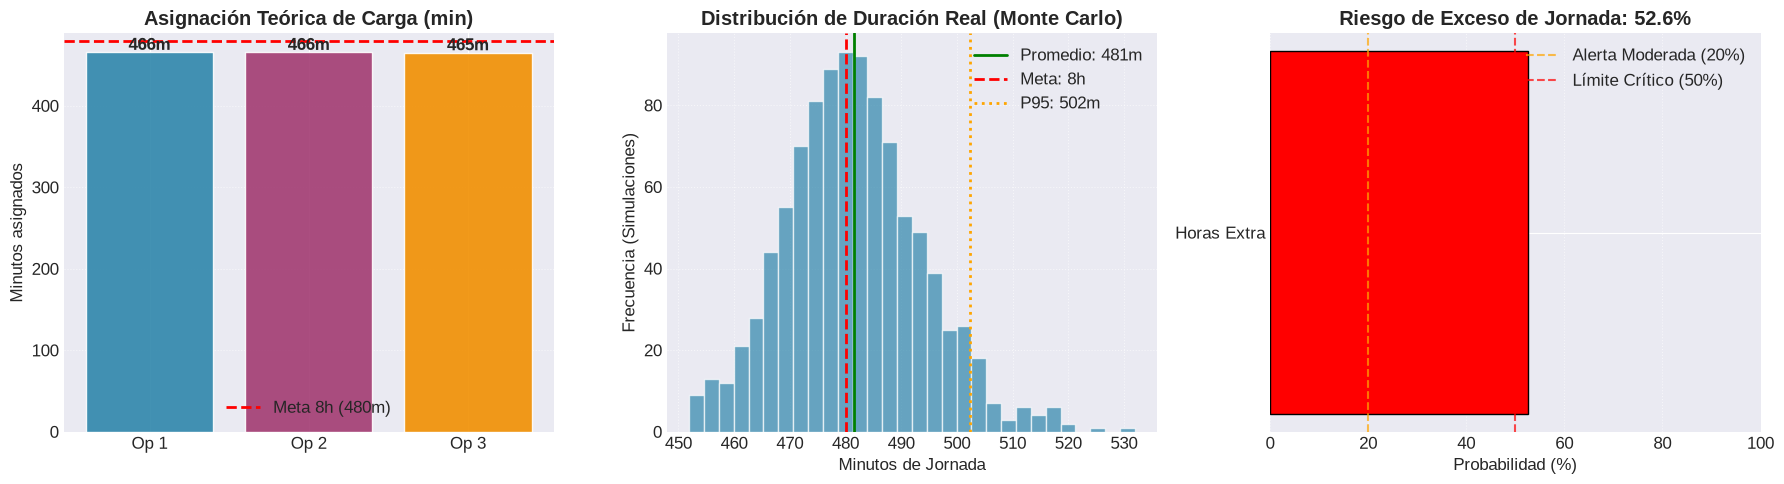

✔ Dashboard de diagnósticos guardado con éxito en: /home/migue07/Documents/Proyectos/optimizacion_despachos/notebooks/../src/../reports/figures/diagnostico_jornada.png


ESCENARIO 2: Omitido
   No se configuraron eventos. Solo se ejecutó el Escenario 1.
   Para ver el impacto de eventos, configura MIS_EVENTOS.


COMPARATIVA DE ESCENARIOS

Escenario                                Makespan P95    Prob. H.Extra   Veredicto                
-----------------------------------------------------------------------------------------------
Línea Base (sin eventos)                    502 min       52.6%         REQUIERE ATENCIÓN        

Configura MIS_EVENTOS para ver el impacto de reuniones e imprevistos.


RECOMENDACIONES PARA LA JORNADA

⚠ LA JORNADA REQUIERE ATENCIÓN con 3 operadores
   Déficit estimado: 22 min (0.4h)
   Probabilidad de horas extra: 52.6%

   ACCIONES RECOMENDADAS:
   1. Agregar 4º operador
   2. Reducir ~1 rutas del pool
   3. Adelantar inicio en 7 min

PLAN DE CONTINGENCIA:

In [8]:
# ==================================================
# CONFIGURACIÓN DE LA JORNADA
# ==================================================

# Rutas a despachar según planificación
MIS_RUTAS_REALES = [
    213, 252, 253, 254, 255, 256, 257, 258, 260, 261, 263, 264, 266, 211, 209,
    207, 201, 1259, 9389, 9388, 9387, 9386, 9385, 9384, 315, 313, 312, 311, 310,
    309, 308, 307, 306, 304, 303, 301, 9435, 9426, 9425, 9424, 9422, 9419, 9390,
    9371, 9370, 9355, 9353, 9345, 9344, 9340, 9339, 9337, 9326, 9320, 9312, 9311,
    9310, 9305, 8256, 8003, 8002, 7739, 7733, 7729, 7693, 7692, 7690, 7681, 7680,
    7677, 7675, 7663, 7659, 7651, 7649, 7643, 7642, 7640, 7637, 7634, 7631, 7627, 
    7626, 7624, 7604, 7601, 9383    
]

# Parámetros de jornada
MIS_OPERADORES = 3       
MI_HORA_INICIO = 15        # Formato 24 horas
MI_META_HORAS = 8          # Jornada objetivo en horas
MIS_SIMULACIONES = 1000    

# Eventos del día (descomentar para activar)
MIS_EVENTOS = {
    # 'reunion_inicio': {
    #     'hora': '15:30',
    #     'duracion': 15,
    #     'afecta': 'todos',
    #     'tipo': 'programado'
    # },
    # 'descarga_urgente': {
    #     'probabilidad': 0.20,
    #     'duracion_media': 20,
    #     'duracion_std': 10,
    #     'afecta': 'aleatorio',
    #     'tipo': 'aleatorio'
    # }
}

# ==================================================
# EJECUCIÓN DE LA JORNADA
# ==================================================

# Verificación de configuración
print("CONFIGURACIÓN DE LA JORNADA")
print(f"Rutas a despachar: {len(MIS_RUTAS_REALES)}")
print(f"Operadores: {MIS_OPERADORES}")
print(f"Hora de inicio: {MI_HORA_INICIO}:00")
print(f"Meta: {MI_META_HORAS} horas")
print(f"Eventos configurados: {len(MIS_EVENTOS)}")
print(f"Simulaciones: {MIS_SIMULACIONES}")

# Crear UNA SOLA instancia del cargador para toda la jornada
print("\n" + "="*60)
print("INICIALIZANDO CARGADOR DE DATOS (UNA SOLA VEZ)")
print("="*60)
cargador_unico = CargadorDatos()

# ESCENARIO 1: Línea Base (sin eventos)
print("\n")
print("="*60)
print("ESCENARIO 1: Línea Base (sin eventos)")
print("   Evalúa la jornada en condiciones ideales, solo con variabilidad natural.")
print("="*60)

# Usar PlanificadorJornada importado desde src
plan_base = PlanificadorJornada()
plan_base.cargador = cargador_unico

plan_base.configurar(
    rutas=MIS_RUTAS_REALES,
    n_operadores=MIS_OPERADORES,
    eventos_dia={},
    hora_inicio=MI_HORA_INICIO,
    meta_horas=MI_META_HORAS,
    n_simulaciones=MIS_SIMULACIONES,
    seed=42
)

plan_base.ejecutar()

# Mostrar asignación detallada
print("\n")
print("ASIGNACIÓN DE RUTAS POR OPERADOR")

df_asig = plan_base.resultado_opt['df_asignacion']
for op in sorted(df_asig['operador'].unique()):
    rutas_op = df_asig[df_asig['operador'] == op].sort_values('tiempo_estimado', ascending=False)
    carga = rutas_op['tiempo_estimado'].sum()
    ids = rutas_op['id_ruta'].tolist()
    
    print(f"\nOperador {op}: {len(rutas_op)} rutas | {carga:.0f} min ({carga/60:.1f}h)")
    print(f"   IDs: {ids}")
    
plan_base.mostrar_diagnostico()
plan_base.graficar_resultados()

# ESCENARIO 2: Con Eventos del Día
if MIS_EVENTOS:
    print("\n")
    print("="*60)
    print("ESCENARIO 2: Con Eventos del Día")
    print("   Evalúa el impacto de reuniones e imprevistos configurados.")
    print("="*60)

    plan_eventos = PlanificadorJornada()
    plan_eventos.cargador = cargador_unico

    plan_eventos.configurar(
        rutas=MIS_RUTAS_REALES,
        n_operadores=MIS_OPERADORES,
        eventos_dia=MIS_EVENTOS,
        hora_inicio=MI_HORA_INICIO,
        meta_horas=MI_META_HORAS,
        n_simulaciones=MIS_SIMULACIONES,
        seed=42
    )

    plan_eventos.ejecutar()
    plan_eventos.mostrar_diagnostico()
    plan_eventos.graficar_resultados()
else:
    print("\n")
    print("="*60)
    print("ESCENARIO 2: Omitido")
    print("="*60)
    print("   No se configuraron eventos. Solo se ejecutó el Escenario 1.")
    print("   Para ver el impacto de eventos, configura MIS_EVENTOS.")
    plan_eventos = None

# COMPARATIVA FINAL
print("\n")
print("="*60)
print("COMPARATIVA DE ESCENARIOS")
print("="*60)

if plan_eventos and plan_eventos.diagnostico_completo:
    print(f"\n{'Escenario':<40} {'Makespan P95':<15} {'Prob. H.Extra':<15} {'Impacto':<20} {'Veredicto':<25}")
    print("-"*115)
    
    d1 = plan_base.diagnostico_completo
    d2 = plan_eventos.diagnostico_completo
    
    makespan1 = d1['simulacion']['p95_makespan']
    makespan2 = d2['simulacion']['p95_makespan']
    impacto = makespan2 - makespan1
    
    print(f"{'Línea Base (sin eventos)':<40} {makespan1:>6.0f} min      {d1['simulacion']['prob_horas_extra']:>5.1f}%         {'--':<20} {d1['viabilidad']['estado']:<25}")
    print(f"{'Con Eventos del Día':<40} {makespan2:>6.0f} min      {d2['simulacion']['prob_horas_extra']:>5.1f}%         {'+' + str(int(impacto)) + ' min':<20} {d2['viabilidad']['estado']:<25}")
    
    print(f"\nImpacto de los eventos: +{impacto:.0f} min ({impacto/60:.1f}h) adicionales en el makespan P95")
else:
    print(f"\n{'Escenario':<40} {'Makespan P95':<15} {'Prob. H.Extra':<15} {'Veredicto':<25}")
    print("-"*95)
    
    d1 = plan_base.diagnostico_completo
    makespan1 = d1['simulacion']['p95_makespan']
    
    print(f"{'Línea Base (sin eventos)':<40} {makespan1:>6.0f} min      {d1['simulacion']['prob_horas_extra']:>5.1f}%         {d1['viabilidad']['estado']:<25}")
    print(f"\nConfigura MIS_EVENTOS para ver el impacto de reuniones e imprevistos.")

# RECOMENDACIÓN FINAL
print("\n")
print("="*60)
print("RECOMENDACIONES PARA LA JORNADA")
print("="*60)

d = plan_base.diagnostico_completo
v = d['viabilidad']
r = d['resumen']
reb = d['rebalanceo']

if v['viable']:
    print(f"\n✓ LA JORNADA ES VIABLE con {MIS_OPERADORES} operadores")
    print(f"   Makespan esperado (promedio): {r['makespan_simulado']:.0f} min ({r['makespan_simulado']/60:.1f}h)")
    print(f"   Makespan P95 (peor caso): {r['makespan_p95']:.0f} min ({r['makespan_p95']/60:.1f}h)")
    print(f"   Holgura: {v['holgura_min']:.0f} min ({v['holgura_horas']:.1f}h)")
    print(f"   Probabilidad de horas extra: {r['prob_horas_extra']:.1f}%")
    
    if v['nivel'] == 'AJUSTADA':
        print(f"\n⚠ La holgura es pequeña. Cualquier imprevisto podría generar horas extra.")
    elif v['nivel'] == 'CÓMODA':
        print(f"\n✓ Hay margen suficiente para absorber imprevistos menores.")
else:
    deficit = abs(v['holgura_min'])
    print(f"\n⚠ LA JORNADA REQUIERE ATENCIÓN con {MIS_OPERADORES} operadores")
    print(f"   Déficit estimado: {deficit:.0f} min ({deficit/60:.1f}h)")
    print(f"   Probabilidad de horas extra: {r['prob_horas_extra']:.1f}%")
    print(f"\n   ACCIONES RECOMENDADAS:")
    print(f"   1. Agregar {MIS_OPERADORES + 1}º operador")
    print(f"   2. Reducir ~{int(deficit/15)} rutas del pool")
    print(f"   3. Adelantar inicio en {int(deficit/MIS_OPERADORES)} min")

# Análisis de rebalanceo
if reb.get('probabilidad_rebalanceo_global', 0) > 20:
    print(f"\nPLAN DE CONTINGENCIA:")
    print(f"   Probabilidad de necesitar rebalanceo: {reb['probabilidad_rebalanceo_global']:.1f}%")
    print(f"   Recomendación: {reb.get('recomendacion', 'N/A')}")
    if reb.get('momentos_criticos'):
        for mc in reb['momentos_criticos'][:2]:
            hora_real = MI_HORA_INICIO + mc['hora_jornada']
            print(f"   Monitorear a las {hora_real}:00 hrs ({mc['probabilidad_retraso']:.0f}% prob. retraso)")

print("\n")
print("="*60)
print("DIAGNÓSTICO COMPLETADO")
print("="*60)


## 8. Validación Retrospectiva

### Objetivo

Comparar la simulación contra una jornada real ya ocurrida para medir 
la precisión del sistema y calibrar la confianza en las predicciones.

### ¿Qué evalúa?

| Métrica | Descripción | Interpretación |
|---------|-------------|----------------|
| **Error absoluto** | Diferencia entre makespan simulado y duración real | < 30 min = bueno |
| **Error porcentual** | Error relativo a la duración real | < 10% = excelente |
| **Cobertura** | ¿La duración real cayó dentro del rango P5-P95? | Sí = modelo confiable |

### Metodología

1. Cargar las rutas reales de una fecha específica del histórico
2. Predecir tiempos con el Random Forest
3. Optimizar asignación con PuLP
4. Simular con Monte Carlo
5. Comparar makespan simulado vs duración real registrada

In [9]:
# Validación retrospectiva

def validar_jornada_personal(fecha_prueba, n_iteraciones=500, seed=42, cargador=None):
    """
    Compara la simulación contra lo que realmente tomó la jornada.
    
    Args:
        fecha_prueba: Fecha a evaluar (debe existir en tu CSV)
        n_iteraciones: Iteraciones Monte Carlo
        seed: Semilla para reproducibilidad
        cargador: Instancia de CargadorDatos (opcional, para reutilizar)
    
    Returns:
        dict con comparativa detallada
    """
    # IMPORTAR DENTRO DE LA FUNCIÓN PARA ASEGURAR DISPONIBILIDAD
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    print("\n")
    print("="*70)
    print(f"VALIDACIÓN RETROSPECTIVA - Jornada Personal")
    print(f"Fecha evaluada: {fecha_prueba}")
    print("="*70)
    
    # 1. Cargar datos y filtrar por fecha
    # CORRECCION: Reutilizar cargador si se proporciona
    if cargador is None:
        cargador = CargadorDatos()
    
    df_historico = cargador.df_historico
    
    if 'fecha' not in df_historico.columns:
        print("ERROR: El dataset no tiene columna 'fecha'.")
        return None
    
    # Convertir fecha a datetime para comparación segura
    df_historico['fecha'] = pd.to_datetime(df_historico['fecha'])
    fecha_prueba_dt = pd.to_datetime(fecha_prueba)
    
    df_dia = df_historico[df_historico['fecha'] == fecha_prueba_dt].copy()
    
    if len(df_dia) == 0:
        fechas_disponibles = sorted(df_historico['fecha'].unique())
        print(f"Fecha '{fecha_prueba}' no encontrada.")
        print(f"Fechas disponibles (últimas 10): {fechas_disponibles[-10:]}")
        return None
    
    print(f"\n✓ Tus rutas ese día: {len(df_dia)}")
    
    # 2. Extraer duración real de TU jornada
    hora_inicio_real = None
    hora_fin_real = None
    duracion_real = None
    
    # Opción A: Usar columna 'horas_jornada' (ya calculada en Fase 1)
    if 'horas_jornada' in df_dia.columns:
        horas_jornada = df_dia['horas_jornada'].iloc[0]
        duracion_real = horas_jornada * 60
        print(f"Duración real (de columna horas_jornada): {duracion_real:.0f} min ({duracion_real/60:.2f} horas)")
    
    # Opción B: Calcular desde hora_inicio y hora_fin (respaldo)
    if duracion_real is None:
        if 'hora_inicio_jornada' in df_dia.columns:
            hora_inicio_real = str(df_dia['hora_inicio_jornada'].iloc[0])
        if 'hora_fin_jornada' in df_dia.columns:
            hora_fin_real = str(df_dia['hora_fin_jornada'].iloc[0])
        
        if hora_inicio_real and hora_fin_real:
            try:
                h_i, m_i, s_i = map(int, hora_inicio_real.split(':'))
                h_f, m_f, s_f = map(int, hora_fin_real.split(':'))
                
                minutos_inicio = h_i * 60 + m_i
                minutos_fin = h_f * 60 + m_f
                
                duracion_real = minutos_fin - minutos_inicio
                if duracion_real <= 0:
                    duracion_real += 24 * 60
                
                print(f"Hora inicio: {hora_inicio_real}")
                print(f"Hora fin: {hora_fin_real}")
                print(f"Duración real (calculada): {duracion_real:.0f} min ({duracion_real/60:.2f} horas)")
            except Exception as e:
                print(f"Error al parsear horas: {e}")
    
    if duracion_real is None or duracion_real <= 0:
        print("No se pudo calcular la duración real.")
        return None
    
    # Tiempo total de preparación (suma de tiempos por ruta)
    tiempo_total_real = None
    if 'tiempo_preparacion_minutos' in df_dia.columns:
        tiempo_total_real = df_dia['tiempo_preparacion_minutos'].sum()
        print(f"Tiempo neto de preparación (suma rutas): {tiempo_total_real:.0f} min ({tiempo_total_real/60:.2f} horas)")
        if duracion_real > tiempo_total_real:
            pausas = duracion_real - tiempo_total_real
            print(f"Tiempo no productivo (pausas, interrupciones): {pausas:.0f} min ({pausas/60:.2f} horas)")
    
    # 3. Ejecutar planificación con 1 SOLO OPERADOR
    rutas_ids = df_dia['id_ruta'].tolist()
    
    # Extraer hora de inicio
    if hora_inicio_real:
        try:
            h_i = int(hora_inicio_real.split(':')[0])
        except:
            h_i = 7
    elif 'hora_inicio_jornada' in df_dia.columns:
        try:
            h_i = int(str(df_dia['hora_inicio_jornada'].iloc[0]).split(':')[0])
        except:
            h_i = 7
    else:
        h_i = 7
    
    print(f"\nSimulando con 1 operador y las {len(rutas_ids)} rutas...")
    
    # CORRECCION: Reutilizar el cargador
    plan = PlanificadorJornada()
    plan.cargador = cargador
    
    plan.configurar(
        rutas=rutas_ids,
        n_operadores=1,
        eventos_dia={},
        hora_inicio=h_i,
        meta_horas=8,
        n_simulaciones=n_iteraciones,
        seed=seed
    )
    plan.ejecutar()
    
    # 4. Extraer resultados simulados
    makespan_simulado = plan.resultado_sim['mean_makespan']
    makespan_p95 = plan.resultado_sim['p95_makespan']
    makespan_p05 = np.percentile(plan.resultado_sim['makespans'], 5)
    std_makespan = plan.resultado_sim['std_makespan']
    
    # 5. Calcular errores
    error_abs = abs(makespan_simulado - duracion_real)
    error_pct = (error_abs / duracion_real) * 100 if duracion_real > 0 else 0
    
    if tiempo_total_real:
        error_abs_neto = abs(makespan_simulado - tiempo_total_real)
        error_pct_neto = (error_abs_neto / tiempo_total_real) * 100 if tiempo_total_real > 0 else 0
    else:
        error_abs_neto = None
        error_pct_neto = None
    
    # 6. Verificar cobertura
    dentro_rango = makespan_p05 <= duracion_real <= makespan_p95
    
    # 7. Evaluación cualitativa
    if error_pct < 10:
        precision = "BUENA ✓"
    elif error_pct < 20:
        precision = "ACEPTABLE"
    else:
        precision = "MEJORABLE"
    
    # 8. Mostrar comparativa
    print("\n")
    print("="*70)
    print("COMPARATIVA: SIMULADO vs REAL (Jornada Personal)")
    print("="*70)
    
    print(f"\nDATOS REALES ({fecha_prueba}):")
    print(f"   Tus rutas despachadas: {len(df_dia)}")
    print(f"   Duración real (reloj): {duracion_real:.0f} min ({duracion_real/60:.1f}h)")
    if tiempo_total_real:
        print(f"   Tiempo neto preparación: {tiempo_total_real:.0f} min ({tiempo_total_real/60:.1f}h)")
        pausas = duracion_real - tiempo_total_real
        print(f"   Pausas/interrupciones: {pausas:.0f} min ({pausas/60:.1f}h)")
    
    print(f"\nRESULTADOS SIMULADOS:")
    print(f"   Makespan promedio: {makespan_simulado:.0f} min ({makespan_simulado/60:.1f}h)")
    print(f"   Makespan P95: {makespan_p95:.0f} min ({makespan_p95/60:.1f}h)")
    print(f"   Rango P5-P95: [{makespan_p05:.0f} - {makespan_p95:.0f}] min")
    print(f"   Desviación std: {std_makespan:.0f} min")
    
    print(f"\nPRECISIÓN DEL MODELO:")
    print(f"   vs Duración real (reloj):")
    print(f"      Error: {error_abs:.0f} min ({error_pct:.1f}%) → {precision}")
    print(f"      ¿Realidad dentro del rango P5-P95?: {'SÍ ✓' if dentro_rango else 'NO ✗'}")
    
    if tiempo_total_real and error_abs_neto is not None:
        print(f"   vs Tiempo neto (sin pausas):")
        print(f"      Error: {error_abs_neto:.0f} min ({error_pct_neto:.1f}%)")
        if error_pct_neto < 5:
            print(f"      → El modelo predice muy bien el tiempo de preparación pura")
        elif error_pct_neto < 15:
            print(f"      → Precisión aceptable considerando la variabilidad natural")
        else:
            print(f"      → Hay diferencias significativas. Revisar calidad de predicciones")
    
    if not dentro_rango:
        if duracion_real < makespan_p05:
            print(f"\n   → La jornada real fue MÁS RÁPIDA que lo simulado")
            print(f"   → Posible mejora: reducir tiempos estimados de rutas")
        else:
            print(f"\n   → La jornada real fue MÁS LENTA que lo simulado")
            print(f"   → Posibles causas: pausas no registradas, fatiga, interrupciones")
    
    # 9. Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Barras comparativas
    ax1 = axes[0]
    categorias = ['Duración\nReal']
    valores = [duracion_real]
    colores = ['steelblue']
    
    categorias.append('Makespan\nSimulado')
    valores.append(makespan_simulado)
    colores.append('orange')
    
    if tiempo_total_real:
        categorias.append('Tiempo Neto\nPreparación')
        valores.append(tiempo_total_real)
        colores.append('lightgreen')
    
    bars = ax1.bar(categorias, valores, color=colores, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val:.0f} min\n({val/60:.1f}h)', ha='center', fontsize=10)
    
    ax1.set_ylabel('Minutos')
    ax1.set_title(f'Tu Jornada: Real vs Simulada\n{fecha_prueba}', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Gráfico 2: Distribución del makespan simulado
    ax2 = axes[1]
    ax2.hist(plan.resultado_sim['makespans'], bins=25, color='steelblue',
             edgecolor='white', alpha=0.7, label=f'Simulaciones ({n_iteraciones})')
    ax2.axvline(x=duracion_real, color='green', linewidth=3,
                label=f'Real: {duracion_real:.0f} min')
    ax2.axvline(x=makespan_simulado, color='orange', linewidth=2,
                linestyle='--', label=f'Sim: {makespan_simulado:.0f} min')
    if tiempo_total_real:
        ax2.axvline(x=tiempo_total_real, color='lightgreen', linewidth=2,
                    linestyle=':', label=f'Neto: {tiempo_total_real:.0f} min')
    
    ax2.set_xlabel('Minutos')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title(f'Distribución de Makespan\nError: {error_abs:.0f} min ({error_pct:.1f}%)',
                  fontweight='bold')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_PATH, f'validacion_personal_{fecha_prueba}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Gráfico guardado en: {REPORTS_PATH}")
    print("="*70)
    
    return {
        'fecha': fecha_prueba,
        'n_rutas': len(df_dia),
        'duracion_real_min': duracion_real,
        'tiempo_neto_real_min': tiempo_total_real,
        'makespan_simulado_min': makespan_simulado,
        'makespan_p95_min': makespan_p95,
        'error_abs_min': error_abs,
        'error_pct': error_pct,
        'error_abs_neto_min': error_abs_neto,
        'error_pct_neto': error_pct_neto,
        'precision': precision,
        'cobertura': dentro_rango,
        'planificador': plan
    }